In [3]:
import pandas as pd
import numpy as np

In [4]:
df = pd.read_csv('../data/creditcard.csv')

# basic df check - shape and structure
print(df.shape)
print(df.dtypes)
print(df.isnull().sum())

# target variable
print(df['Class'].value_counts())

# look at the features
print(df.head())
print(df.describe())

(284807, 31)
Time      float64
V1        float64
V2        float64
V3        float64
V4        float64
V5        float64
V6        float64
V7        float64
V8        float64
V9        float64
V10       float64
V11       float64
V12       float64
V13       float64
V14       float64
V15       float64
V16       float64
V17       float64
V18       float64
V19       float64
V20       float64
V21       float64
V22       float64
V23       float64
V24       float64
V25       float64
V26       float64
V27       float64
V28       float64
Amount    float64
Class       int64
dtype: object
Time      0
V1        0
V2        0
V3        0
V4        0
V5        0
V6        0
V7        0
V8        0
V9        0
V10       0
V11       0
V12       0
V13       0
V14       0
V15       0
V16       0
V17       0
V18       0
V19       0
V20       0
V21       0
V22       0
V23       0
V24       0
V25       0
V26       0
V27       0
V28       0
Amount    0
Class     0
dtype: int64
Class
0    284315
1       492


In [5]:
# normalize amount field
from sklearn.preprocessing import StandardScaler
scaler = StandardScaler()
df['Amount'] = scaler.fit_transform(df[['Amount']])
df = df.drop(columns=['Time'])

print(df.shape)

(284807, 30)


In [6]:
print(df['Amount'].describe())

count    2.848070e+05
mean    -3.672378e-17
std      1.000002e+00
min     -3.532294e-01
25%     -3.308401e-01
50%     -2.652715e-01
75%     -4.471707e-02
max      1.023622e+02
Name: Amount, dtype: float64


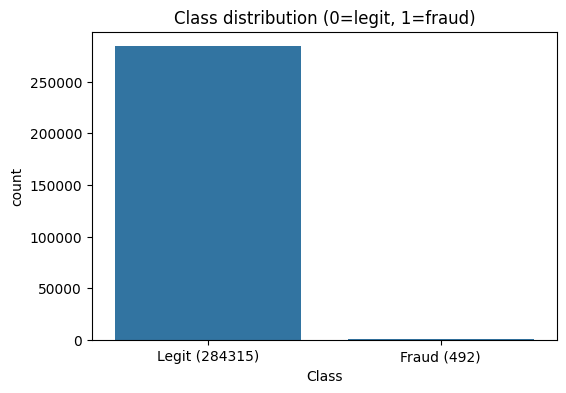

In [7]:
import matplotlib.pyplot as plt
import seaborn as sns

# 1. Class distribution
plt.figure(figsize=(6,4))
sns.countplot(x='Class', data=df)
plt.title('Class distribution (0=legit, 1=fraud)')
plt.xticks([0,1], ['Legit (284315)', 'Fraud (492)'])
plt.show()

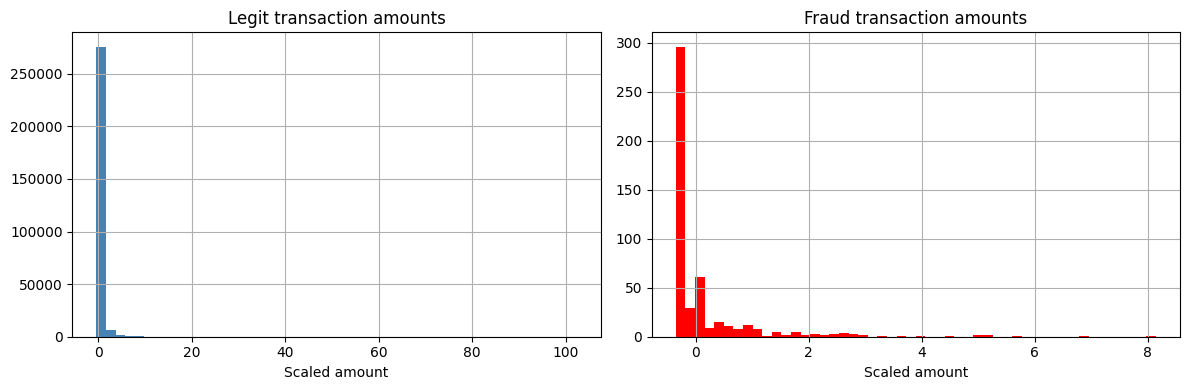

In [8]:
# 2. Amount distribution by class — side by side
fig, axes = plt.subplots(1, 2, figsize=(12, 4))

df[df['Class']==0]['Amount'].hist(ax=axes[0], bins=50, color='steelblue')
axes[0].set_title('Legit transaction amounts')
axes[0].set_xlabel('Scaled amount')

df[df['Class']==1]['Amount'].hist(ax=axes[1], bins=50, color='red')
axes[1].set_title('Fraud transaction amounts')
axes[1].set_xlabel('Scaled amount')

plt.tight_layout()
plt.show()

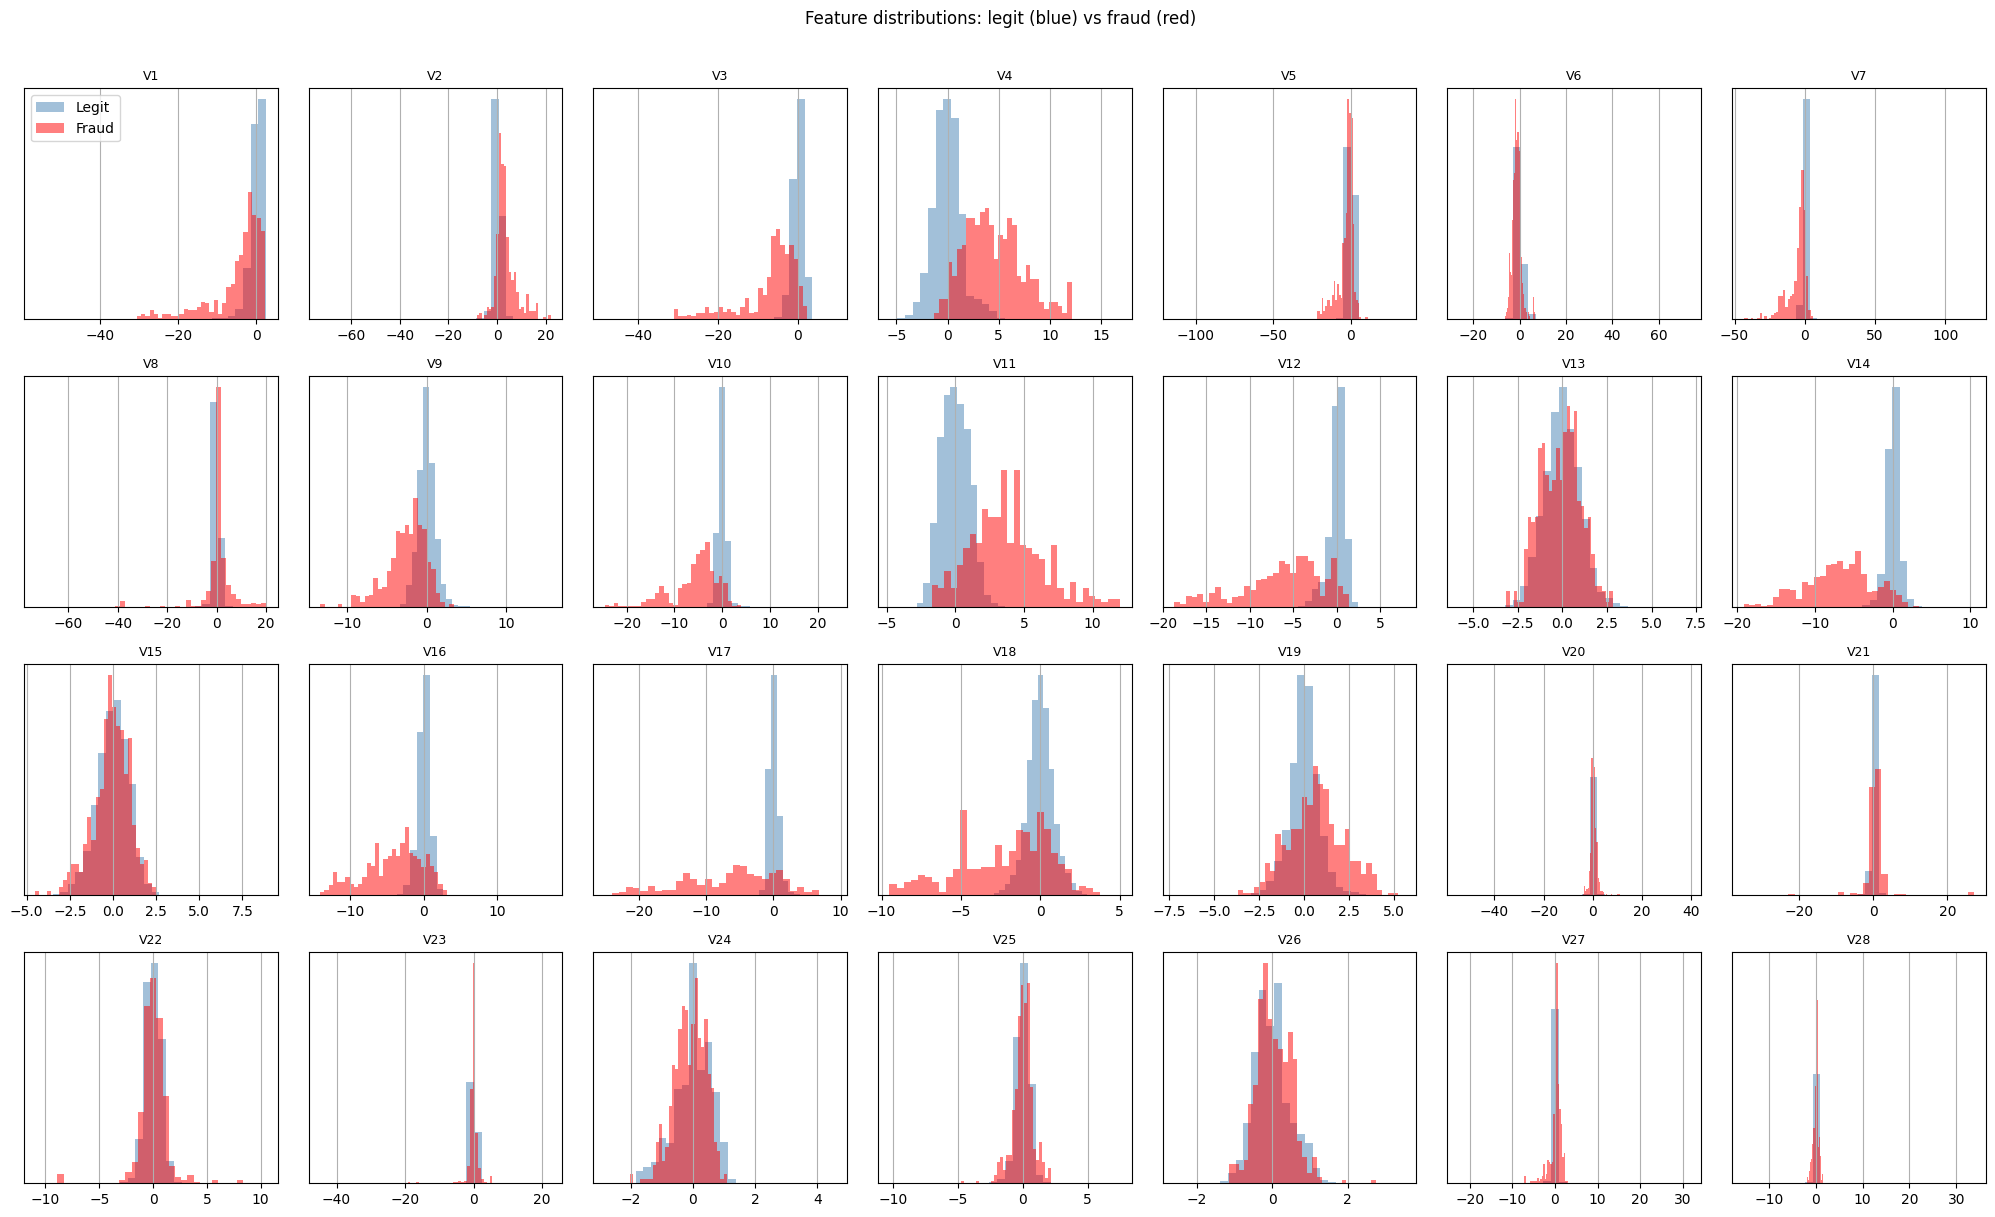

In [9]:
# 3. Find which V-features separate fraud vs legit best
fig, axes = plt.subplots(4, 7, figsize=(20, 12))
axes = axes.flatten()

for i, col in enumerate([f'V{j}' for j in range(1, 29)]):
    df[df['Class']==0][col].hist(ax=axes[i], bins=30, alpha=0.5, 
                                  color='steelblue', label='Legit', density=True)
    df[df['Class']==1][col].hist(ax=axes[i], bins=30, alpha=0.5, 
                                  color='red', label='Fraud', density=True)
    axes[i].set_title(col, fontsize=9)
    axes[i].set_yticks([])

axes[0].legend()
plt.suptitle('Feature distributions: legit (blue) vs fraud (red)', y=1.01)
plt.tight_layout()
plt.show()

In [10]:
from sklearn.model_selection import train_test_split

X = df.drop('Class', axis=1)
y = df['Class']

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

print("Training set size:", X_train.shape)
print("Test set size:", X_test.shape)
print("\nClass distribution in training set:")
print(y_train.value_counts())
print("\nClass distribution in test set:")
print(y_test.value_counts())

Training set size: (227845, 29)
Test set size: (56962, 29)

Class distribution in training set:
Class
0    227451
1       394
Name: count, dtype: int64

Class distribution in test set:
Class
0    56864
1       98
Name: count, dtype: int64


In [11]:
from imblearn.over_sampling import SMOTE

smote = SMOTE(random_state=42)
X_train_res, y_train_res = smote.fit_resample(X_train, y_train)

print("Before SMOTE:", y_train.value_counts().to_dict())
print("After SMOTE: ", y_train_res.value_counts().to_dict())

Before SMOTE: {0: 227451, 1: 394}
After SMOTE:  {0: 227451, 1: 227451}


In [13]:
# training xgboost model
from xgboost import XGBClassifier

model = XGBClassifier(
    n_estimators=100,
    max_depth=6,
    learning_rate=0.1,
    eval_metric='logloss',
    random_state=42
)

model.fit(
    X_train_res, y_train_res,
    eval_set=[(X_test, y_test)],
    verbose=10
)

[0]	validation_0-logloss:0.60848
[10]	validation_0-logloss:0.22121
[20]	validation_0-logloss:0.10683
[30]	validation_0-logloss:0.06589
[40]	validation_0-logloss:0.04917
[50]	validation_0-logloss:0.03912
[60]	validation_0-logloss:0.03150
[70]	validation_0-logloss:0.02632
[80]	validation_0-logloss:0.02227
[90]	validation_0-logloss:0.01910
[99]	validation_0-logloss:0.01647


,"objective objective: typing.Union[str, xgboost.sklearn._SklObjWProto, typing.Callable[[typing.Any, typing.Any], typing.Tuple[numpy.ndarray, numpy.ndarray]], NoneType]Specify the learning task and the corresponding learning objective or a customobjective function to be used.For custom objective, see :doc:`/tutorials/custom_metric_obj` and:ref:`custom-obj-metric` for more information, along with the end note forfunction signatures.",'binary:logistic'
,"base_score base_score: typing.Union[float, typing.List[float], NoneType]The initial prediction score of all instances, global bias.",None
,booster,None
,"callbacks callbacks: typing.Optional[typing.List[xgboost.callback.TrainingCallback]]List of callback functions that are applied at end of each iteration.It is possible to use predefined callbacks by using:ref:`Callback API `... note:: States in callback are not preserved during training, which means callback objects can not be reused for multiple training sessions without reinitialization or deepcopy... code-block:: python for params in parameters_grid: # be sure to (re)initialize the callbacks before each run callbacks = [xgb.callback.LearningRateScheduler(custom_rates)] reg = xgboost.XGBRegressor(**params, callbacks=callbacks) reg.fit(X, y)",None
,colsample_bylevel colsample_bylevel: typing.Optional[float]Subsample ratio of columns for each level.,None
,colsample_bynode colsample_bynode: typing.Optional[float]Subsample ratio of columns for each split.,None
,colsample_bytree colsample_bytree: typing.Optional[float]Subsample ratio of columns when constructing each tree.,None
,"device device: typing.Optional[str].. versionadded:: 2.0.0Device ordinal, available options are `cpu`, `cuda`, and `gpu`.",None
,"early_stopping_rounds early_stopping_rounds: typing.Optional[int].. versionadded:: 1.6.0- Activates early stopping. Validation metric needs to improve at least once in every **early_stopping_rounds** round(s) to continue training. Requires at least one item in **eval_set** in :py:meth:`fit`.- If early stopping occurs, the model will have two additional attributes: :py:attr:`best_score` and :py:attr:`best_iteration`. These are used by the :py:meth:`predict` and :py:meth:`apply` methods to determine the optimal number of trees during inference. If users want to access the full model (including trees built after early stopping), they can specify the `iteration_range` in these inference methods. In addition, other utilities like model plotting can also use the entire model.- If you prefer to discard the trees after `best_iteration`, consider using the callback function :py:class:`xgboost.callback.EarlyStopping`.- If there's more than one item in **eval_set**, the last entry will be used for early stopping. If there's more than one metric in **eval_metric**, the last metric will be used for early stopping.",None
,enable_categorical enable_categorical: boolSee the same parameter of :py:class:`DMatrix` for details.,False
,"eval_metric eval_metric: typing.Union[str, typing.List[typing.Union[str, typing.Callable]], typing.Callable, NoneType].. versionadded:: 1.6.0Metric used for monitoring the training result and early stopping. It can be astring or list of strings as names of predefined metric in XGBoost (See:doc:`/parameter`), one of the metrics in :py:mod:`sklearn.metrics`, or anyother user defined metric that looks like `sklearn.metrics`.If custom objective is also provided, then custom metric should implement thecorresponding reverse link function.Unlike the `scoring` parameter commonly used in scikit-learn, when a callableobject is provided, it's assumed to be a cost function and by default XGBoostwill minimize the result during early stopping.For advanced usage on Early stopping like directly choosing to maximize insteadof minimize, see :py:obj:`xgboost.callback.EarlyStopping`.See :doc:`/tutorials/custom_metric_obj` and :ref:`custom-obj-metric` for moreinformation... code-block:: python from sklearn.datasets import load_diabetes 

In [14]:
import joblib
import os

os.makedirs('../models', exist_ok=True)
joblib.dump(model, '../models/fraud_model.pkl')
joblib.dump(scaler, '../models/scaler.pkl')

print("Model saved successfully")

Model saved successfully


In [15]:
# Make sure model predicts something sensible
sample = X_test.iloc[0:5]
probs = model.predict_proba(sample)[:, 1]
print("Sample fraud probabilities:", probs)
# Should show values between 0 and 1

Sample fraud probabilities: [4.4234493e-04 3.2581051e-04 3.8090028e-04 9.6474650e-05 6.7428462e-03]


In [16]:
from sklearn.metrics import (classification_report, confusion_matrix,
                              roc_auc_score, average_precision_score)
import matplotlib.pyplot as plt
import seaborn as sns

y_pred = model.predict(X_test)
y_prob = model.predict_proba(X_test)[:, 1]

print("Classification Report:")
print(classification_report(y_test, y_pred))
print(f"AUC-ROC:           {roc_auc_score(y_test, y_prob):.4f}")
print(f"Average Precision: {average_precision_score(y_test, y_prob):.4f}")

Classification Report:
              precision    recall  f1-score   support

           0       1.00      1.00      1.00     56864
           1       0.33      0.88      0.48        98

    accuracy                           1.00     56962
   macro avg       0.66      0.94      0.74     56962
weighted avg       1.00      1.00      1.00     56962

AUC-ROC:           0.9739
Average Precision: 0.8150


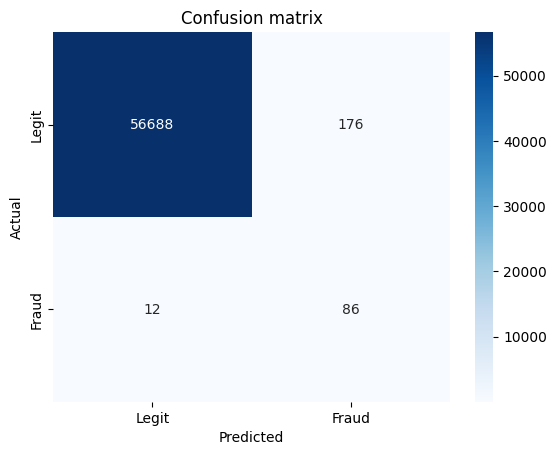

In [17]:
cm = confusion_matrix(y_test, y_pred)
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=['Legit', 'Fraud'],
            yticklabels=['Legit', 'Fraud'])
plt.xlabel('Predicted')
plt.ylabel('Actual')
plt.title('Confusion matrix')
plt.show()

In [18]:
# Try a lower threshold — flag anything above 0.3 as fraud
y_pred_tuned = (y_prob >= 0.3).astype(int)

from sklearn.metrics import classification_report
print(classification_report(y_test, y_pred_tuned))

              precision    recall  f1-score   support

           0       1.00      0.99      1.00     56864
           1       0.18      0.89      0.29        98

    accuracy                           0.99     56962
   macro avg       0.59      0.94      0.64     56962
weighted avg       1.00      0.99      1.00     56962



In [19]:
import shap

explainer = shap.TreeExplainer(model)
shap_values = explainer.shap_values(X_test)

print("SHAP values shape:", shap_values.shape)
# Should match X_test shape — (56962, 29)

SHAP values shape: (56962, 29)


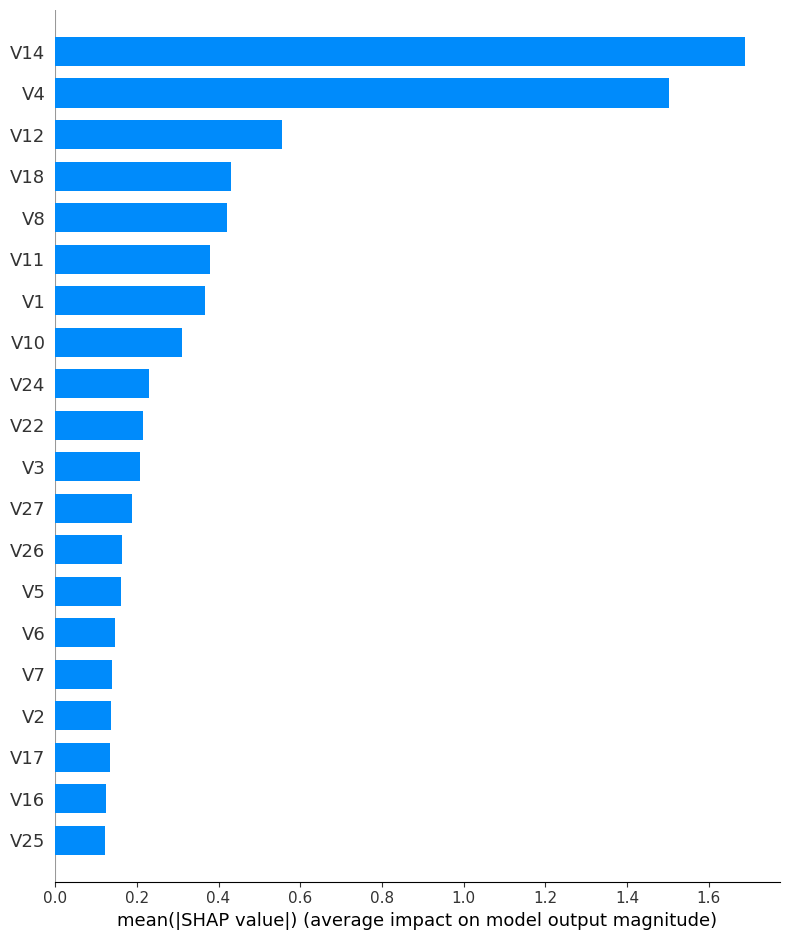

In [20]:
shap.summary_plot(shap_values, X_test, plot_type='bar')

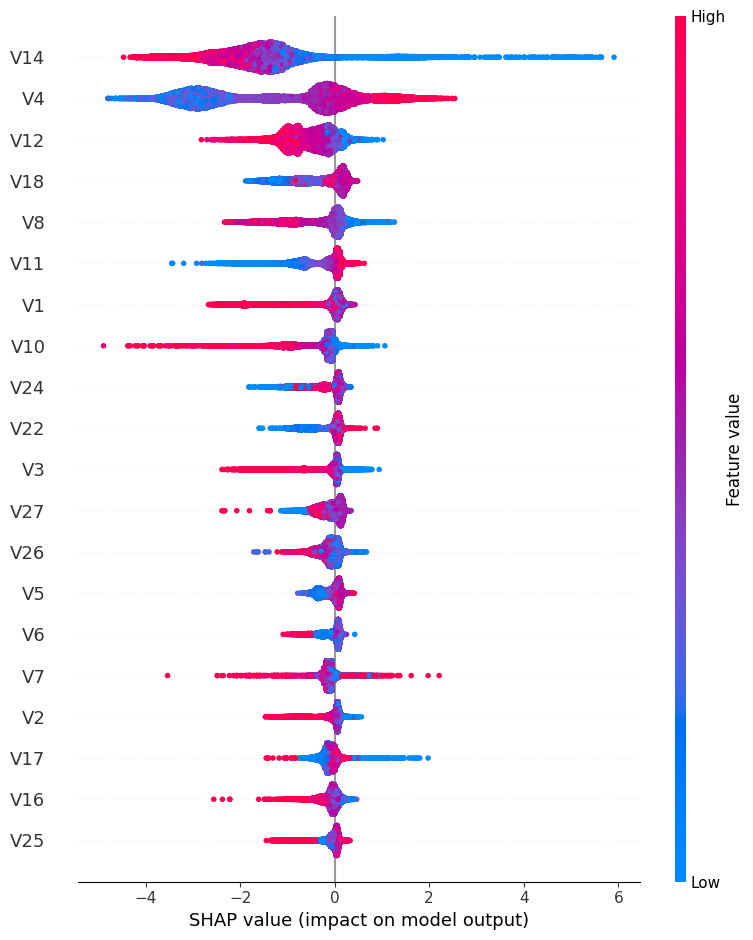

In [21]:
shap.summary_plot(shap_values, X_test)

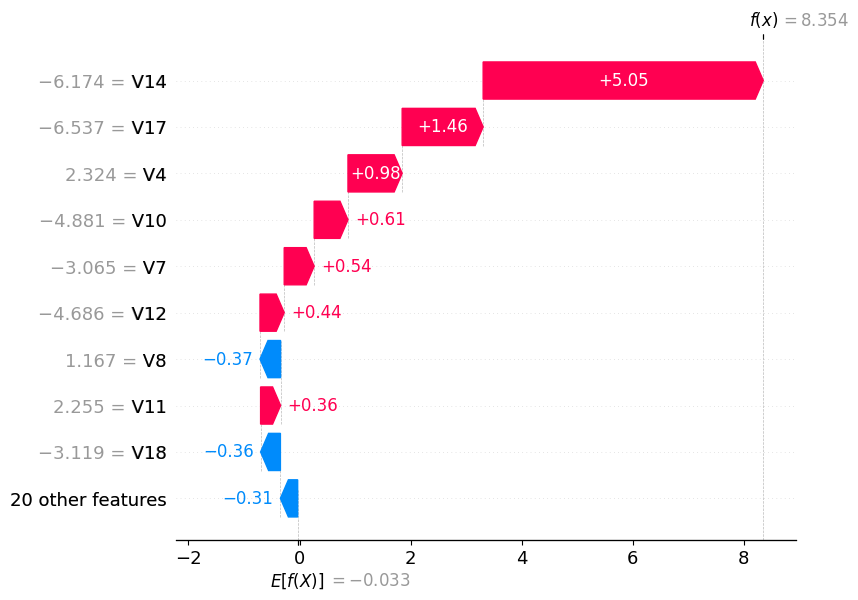

In [22]:
# Pick a fraud transaction to explain
fraud_indices = y_test[y_test == 1].index
sample_idx = fraud_indices[0]

# Get position in X_test
pos = X_test.index.get_loc(sample_idx)

shap.waterfall_plot(shap.Explanation(
    values=shap_values[pos],
    base_values=explainer.expected_value,
    data=X_test.iloc[pos],
    feature_names=X_test.columns.tolist()
))

In [23]:
import joblib
joblib.dump(explainer, '../models/shap_explainer.pkl')
print('Explainer saved')

Explainer saved


In [24]:
fraud_indices = y_test[y_test == 1].index
real_fraud = X_test.loc[fraud_indices[0]]
print(real_fraud.tolist())

[-1.27124419171437, 2.46267526851135, -2.85139500331783, 2.3244800653478, -1.37224488981369, -0.948195686538643, -3.06523436172054, 1.16692694787211, -2.26877058844813, -4.88114292689057, 2.25514748870463, -4.68638689759229, 0.652374668512965, -6.17428834800643, 0.594379608016446, -4.84969238709652, -6.53652073527011, -3.11909388163881, 1.71549441975915, 0.560478075726644, 0.652941051330455, 0.0819309763507574, -0.221347831198339, -0.523582159233306, 0.224228161862968, 0.756334522703558, 0.632800477330469, 0.250187092757197, -0.35318941210488414]
